<h1 align="center">Multiphase Summative Assessment</h1>
<h2 align="center">Introduction to Visual Data Analytics</h2>
<h2 align="center">DV1699 – VT2026</h2>
<h3 align="center">Grace Dona Harlita Tarihoran (grta26@student.bth.se)</h3>

# Introduction

This multiphase summative assessment is an assignment consisting of multiple parts designed to help students practice programming with Python visualization libraries and answer questions related to dataset analysis using visualization.

## Key objectives:

1. Practice Python programming using visualization libraries.
2. Create appropriate visualizations for different types of datasets.
3. Analyze datasets by identifying patterns, trends, and relationships.
4. Interpret visual outputs and explain what the charts show.
5. Answer data analysis questions using evidence from visualizations.
6. Develop skills in presenting findings clearly and accurately.

# Part I: Data Collecting, Processing, and Plotting

Read and process datasets, visualize data with *Python and Matplotlib*, analyze data using visualization techniques, and select an appropriate data representation based on the type of data and/or the question being asked. 

## Case A: Stock Performance Analysis

The dataset includes the daily closing prices (DCPs) of 5 major companies (AAPL, MSFT, GOOGLE, AMZN, TSLA) in USD over 100 trading days.

## CT1. Data Exploration and Static Visualization

### CT1-1: Explore the dataset 

#### (1) Read the dataset in a DataFrame and display the first 5 rows and last 10 rows of the dataset

In [2]:
import pandas as pd

# read the dataset in csv format
df = pd.read_csv("assignment_CaseA_data.csv")

# display the first 5 rows of the dataset by default
df.head()

,date,AAPL,MSFT,GOOGL,AMZN,TSLA
0,2024-08-21,226.40,424.14,165.85,180.11,223.27
1,2024-06-18,214.29,446.34,175.09,182.81,184.86
2,2024-07-11,227.57,454.70,185.57,195.05,241.03
3,2024-06-20,209.68,445.70,176.30,186.10,181.57
4,2024-08-28,226.49,410.60,162.85,170.80,205.75


In [3]:
# display the first 10 rows of the dataset by setting 10 inside the parentheses
df.head(10)

,date,AAPL,MSFT,GOOGL,AMZN,TSLA
0,2024-08-21,226.40,424.14,165.85,180.11,223.27
1,2024-06-18,214.29,446.34,175.09,182.81,184.86
2,2024-07-11,227.57,454.70,185.57,195.05,241.03
3,2024-06-20,209.68,445.70,176.30,186.10,181.57
4,2024-08-28,226.49,410.60,162.85,170.80,205.75
5,2024-06-21,207.49,449.78,179.63,189.08,183.01
6,2024-08-16,226.05,418.47,162.96,177.06,216.12
7,2024-05-14,187.43,416.56,170.34,187.07,177.55
8,2024-09-06,220.82,401.70,150.92,171.39,210.73
9,2024-07-03,221.55,460.77,185.82,197.59,246.39


#### (2) Check whether the dataset contains missing values

In [4]:
# check missing values in the dataset

print("Missing values in each column:")
df.isna().sum()

Missing values in each column:


date     0
AAPL     0
MSFT     0
GOOGL    0
AMZN     0
TSLA     0
dtype: int64

> There are no missing values in the dataset.

#### Methods of processing any missing values.
There are two methods of processing any missing values in a dataset (Skiena, 2017):
1. Drop data with null values (removal method)
   
    This method can be used when we have many rows of data and can safely remove the rows with missing values. However, this should only be done if the missing values are not caused by systematic reasons, such as missing data in time series datasets. In some cases, it is better to impute the missing values with suitable replacement values instead of leaving them blank or removing the rows.

2. Fill null values with a fixed value (imputation method)
   
    This method can be used when we do not have many rows of data or when we want to keep as much of the original dataset as possible. Instead of removing rows with missing values, we can replace the missing values with suitable estimated values. There are several imputation methods that can be used to fill missing values:
    - Mean value imputation: This method uses the mean value of a column to fill in the missing values. It is simple and useful for numerical data, but it may reduce variability in the dataset.
    - Random value imputation: This method fills missing values by randomly selecting values from the existing data. However, this can be considered a weak or unreliable guess if it is not done carefully.
    - Imputation by interpolation: This method estimates missing values based on surrounding or related values, for example by using linear interpolation or regression. It works well when the data follows a clear pattern, such as in time series data.
    - Imputation by nearest neighbour: This method identifies the most similar complete record based on the available fields and uses it to estimate the missing values.

#### (3) Sort the dataset by date from recent to earliest in your code and write text answers of the time span of the dataset.

In [5]:
# sort the dataset by date from recent to earliest

# convert the date coloumn to datetime objects
df["date"] = pd.to_datetime(df["date"])

# sort the dataset from recent to earliest
df_sorted = df.sort_values(by="date", ascending = False)

# calculate the time span
earliest_date = df["date"].min()
latest_date = df["date"].max()
time_span = latest_date - earliest_date

# display the date range and the time span
print(f"The dataset spans from {earliest_date.date()} to {latest_date.date()}.")
print(f"The time span of this dataset is {time_span.days} days.")

The dataset spans from 2024-05-07 to 2024-09-27.
The time span of this dataset is 143 days.


### CT1-2: Comparison and relationship 

#### (1) Visualize the observed DCPs for the company AMZN and highlight its lowest point in the plot.

The lowest DCP was identified by finding the minimum value in the AMZN column and checking the date when it occurred.

The observed DCPs for AMZN were **visualized using a line plot** because:
- the dataset contains price values over time
- this visualization is appropriate for showing trends and fluctuations in AMZN’s DCP
- it also makes it easier to identify periods of volatility and highlight the lowest observed DCP

*Volatility* represents how much and how quickly the price of an asset (like AMZN stock) swings around its average price.
- When volatility is high, there is a lot of uncertainty in the market. Investors aren't sure what the "fair" price should be, so they react sharply to every piece of news.
- When volatility is low, the market is generally calmer and more confident in the current valuation.

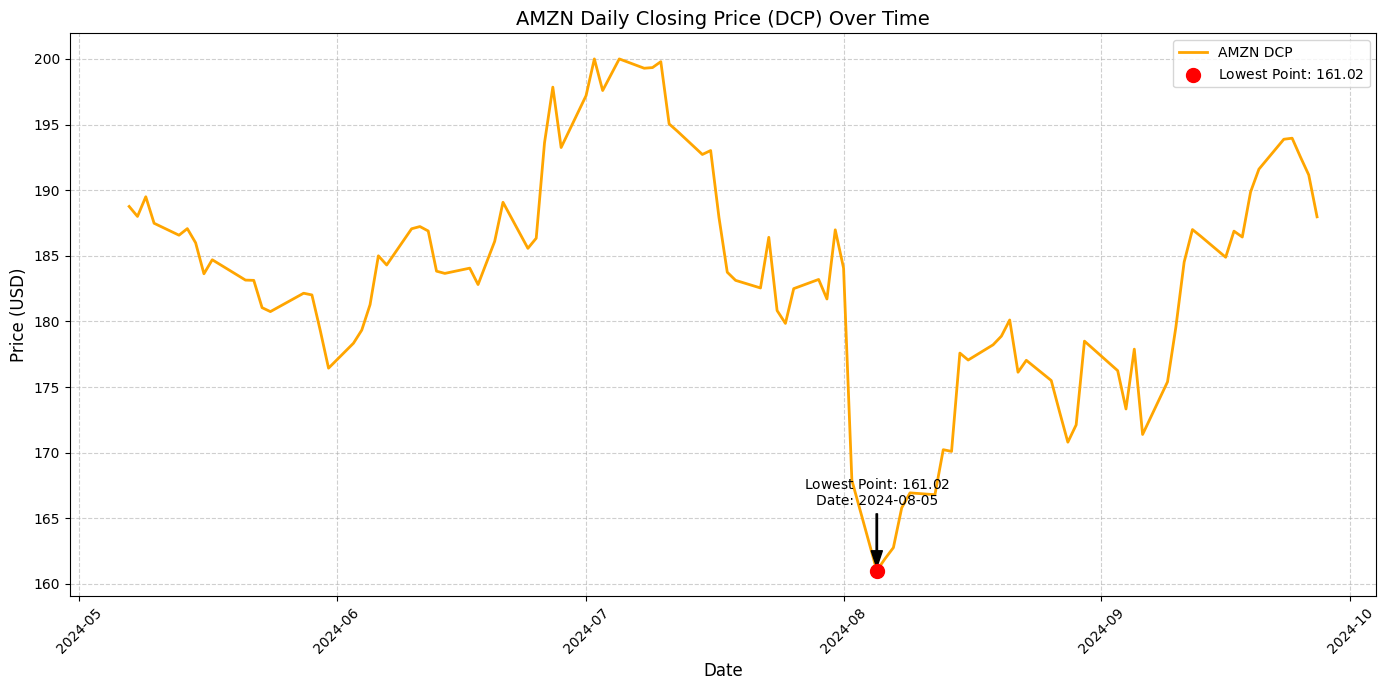

In [7]:
# Import Matplotlib's pyplot module for creating charts and visualizations
import matplotlib.pyplot as plt

# Re-sort ascending for the plot to ensure the line flows left-to-right
df_plot = df_sorted.sort_values(by="date", ascending=True)

# Find the lowest price
min_val = df_plot['AMZN'].min()

# Find the specific date associated with that minimum value
# idxmin() finds the index (row number) of the lowest price
min_date = df_plot.loc[df_plot['AMZN'].idxmin(), 'date']

# Create the Visualization
# Set the size of the plot window (14 inches wide, 7 inches tall)
plt.figure(figsize=(14, 7))

# Plot the AMZN price as a line
# color='orange' matches Amazon's brand, and linewidth=2 makes the line thicker
plt.plot(df_plot['date'], df_plot['AMZN'], label='AMZN DCP', color='orange', linewidth=2)

# Highlight the lowest point
# Draw a single red dot (scatter point) at the lowest price coordinate
# zorder=5 ensures the dot stays on top of the grid and line
plt.scatter(min_date, min_val, color='red', s=100, zorder=5, label=f'Lowest Point: ${min_val}$')

# Add the annotation
# Add a text label and an arrow pointing to the red dot
plt.annotate(f'Lowest Point: ${min_val}$\nDate: {min_date.date()}', 
             xy=(min_date, min_val),      # The point the arrow head touches
             xytext=(min_date, min_val+5), # Position of the text (slightly above the point)
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8), # Style the arrow
             horizontalalignment='center'
             )

# Formatting
# Add the chart title and axis labels
plt.title('AMZN Daily Closing Price (DCP) Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)

# Show the legend (the box explaining what the orange line and red dot mean)
plt.legend()

# Add a dashed background grid to make it easier to trace prices to the Y-axis
plt.grid(True, linestyle='--', alpha=0.6)

# Rotate the date labels on the X-axis by 45 degrees
# This prevents the dates from overlapping and becoming unreadable
plt.xticks(rotation=45)

# Adjust the layout so that labels (especially rotated ones) aren't cut off
plt.tight_layout()

# Display the plot
plt.show()

**Plot Observations**:

- The lowest point value observed in DCP was **161.02**
- This lowest value occurred on **2024-08-05** and this point was highlighted in the plot with red dot
- Around August 5, 2024, the plot shows a sharp V-shape shows that **AMZN had high volatility**. The price went down quickly to its lowest point and then went up again. If the stock had low volatility, the line would look smoother and flatter, without large drops or sudden increases.

#### (2) Compare the DCPs (or stock price movements) of the five companies over time

The most appropriate chart for comparing the stock price movements of multiple companies over time is a **Multi-Line Chart**. This chart type is ideal because it allows multiple companies to be tracked at the same time on a shared time axis (X-axis), making it easier to compare their trends and see whether their prices move in similar or different ways.

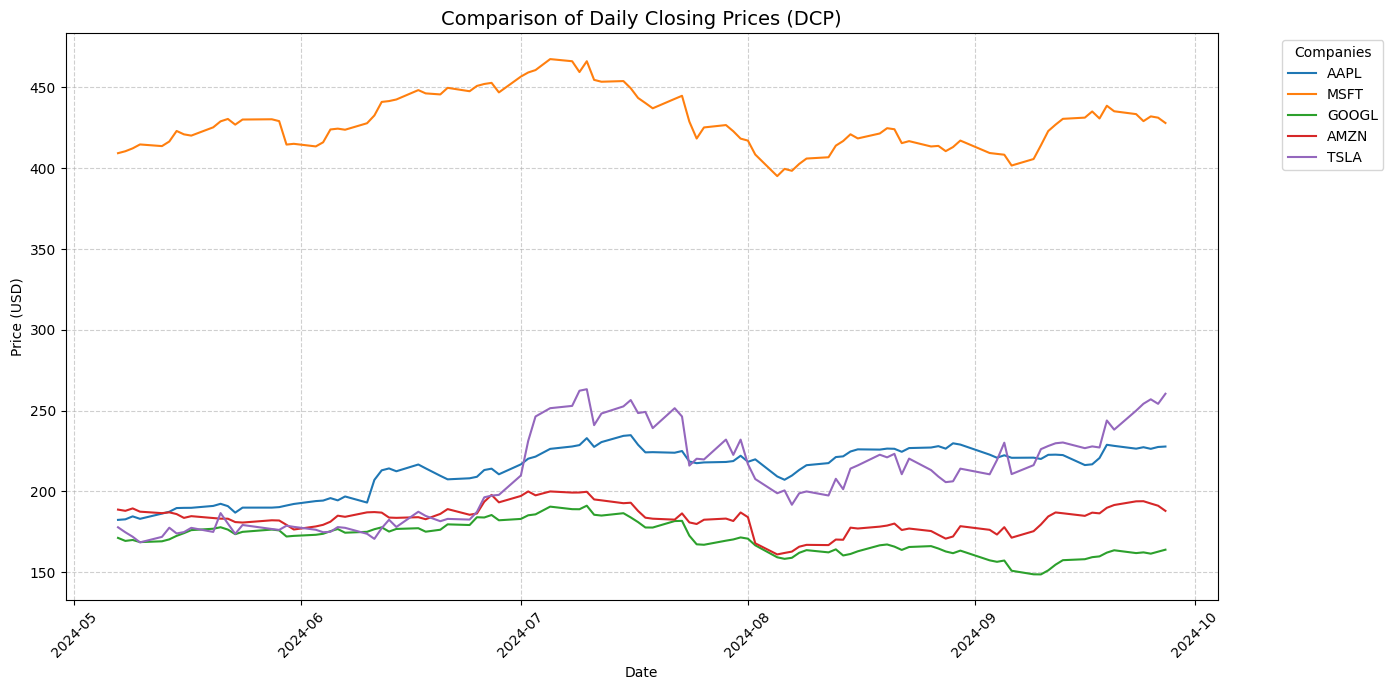

In [8]:
# Create the visualization
plt.figure(figsize=(14, 7))
companies = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']

# Plot each company
for company in companies:
    plt.plot(df_plot['date'], df_plot[company], label=company)

# Formatting
plt.title('Comparison of Daily Closing Prices (DCP)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (USD)')

# 1.05 in X-axis position means slightly outside the right side of the plot
# 1 in Y-axis position means the top of the plot
plt.legend(title='Companies', bbox_to_anchor=(1.05, 1), loc='upper left') # frameon=True if you want to make it onframe

plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()

**Plot Observations:**

1. **Trend Analysis**
- Based on the multi-line chart, the five companies show different stock price movements over time.
- The chart allows the DCPs of AAPL, MSFT, GOOGL, AMZN, and TSLA to be compared on the same time axis.
- Some companies appear to have similar movements because their lines rise and fall in a similar direction.

2. **Similar Trends:**
- MSFT, GOOGL, and AMZN appear to show similar trends in several parts of the plot.
- Their lines often move in a similar direction, meaning they rise and fall at similar times.
- This suggests that these companies may have been influenced by similar market conditions during the observed period.

3. **Divergent Trends:**
- TSLA appears to have a different trend compared with the other companies.
- TSLA shows sharper increases and decreases, which suggests higher volatility.
- AAPL also shows some movements that are different from the other companies in certain parts of the plot.
- Divergent trends can be seen when one company’s line moves upward while another company’s line stays flat or moves downward.

These observations are based on the visual patterns in the plot. To make the analysis clearer and more reliable, statistical correlation could also be used to check how strongly or weakly the companies’ stock prices move together.

#### (3) DCPs analysis of the AAPL company

To identify the price intervals with the highest frequency (most common price ranges) for AAPL, the most appropriate chart is a **Histogram** because it specifically designed to show the distribution of a dataset by grouping values into intervals and showing how many data points fall into each interval.

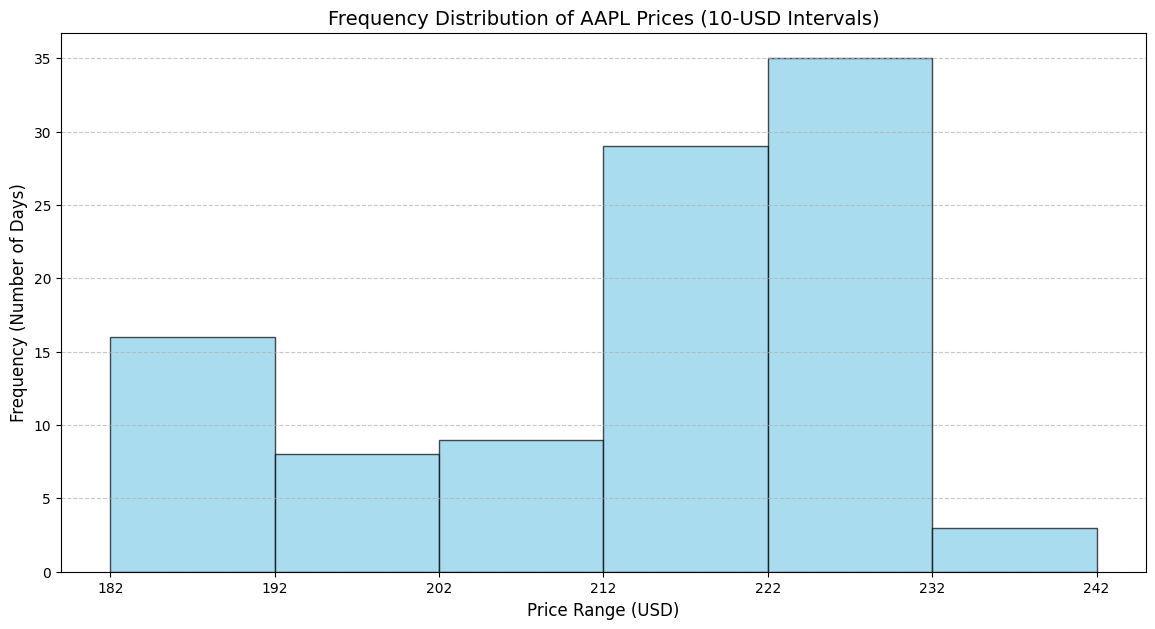

In [9]:
# Import NumPy library for numerical calculations.
# Calculate rounded price limits and create the histogram bins
import numpy as np

# Set the interval size (10 USD)
interval_size = 10

# Define bins from the minimum price to the maximum price, jumping by 10
min_price = np.floor(df['AAPL'].min())
max_price = np.ceil(df['AAPL'].max())
bins = np.arange(min_price, max_price + interval_size, interval_size)

# Create the Histogram
plt.figure(figsize=(14, 7))
plt.hist(df['AAPL'], bins=bins, color='skyblue', edgecolor='black', alpha=0.7)

# Formatting
plt.title('Frequency Distribution of AAPL Prices (10-USD Intervals)', fontsize=14)
plt.xlabel('Price Range (USD)', fontsize=12)
plt.ylabel('Frequency (Number of Days)', fontsize=12)
plt.xticks(bins) # Show the exact interval edges on the X-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.show()

**Plot Observations:**

- The tallest bar in the histogram represents the **Mode** (the most frequent interval). This is the price range where AAPL's stock spent the most amount of time during the period analyzed.
- The X-Axis is the base of that tallest bar tells you the exact interval. For example, if the tallest bar starts at $222$ and ends at $232$, then $\$222 - \$232$ is the most common price interval.
- The height of the bar on the Y-axis tells you exactly how many days the stock was "stuck" in that price range.

*This tells you that $\$222 - \$232$ was the most "comfortable" price for AAPL during this time!*

## Case B: Employee Productivity Analysis

The dataset includes different performance metrics to assess the productivity of 10 employees in R&D, Marketing, and Sales.

## Task 1. Correlation of performance factors

Factors that influence the productivity of an employee are often related to each other to some degree. 
The goal is to determine how the three factors (*hours worked per month, tasks completed, and 
efficiency score*) are correlated among employees across departments.

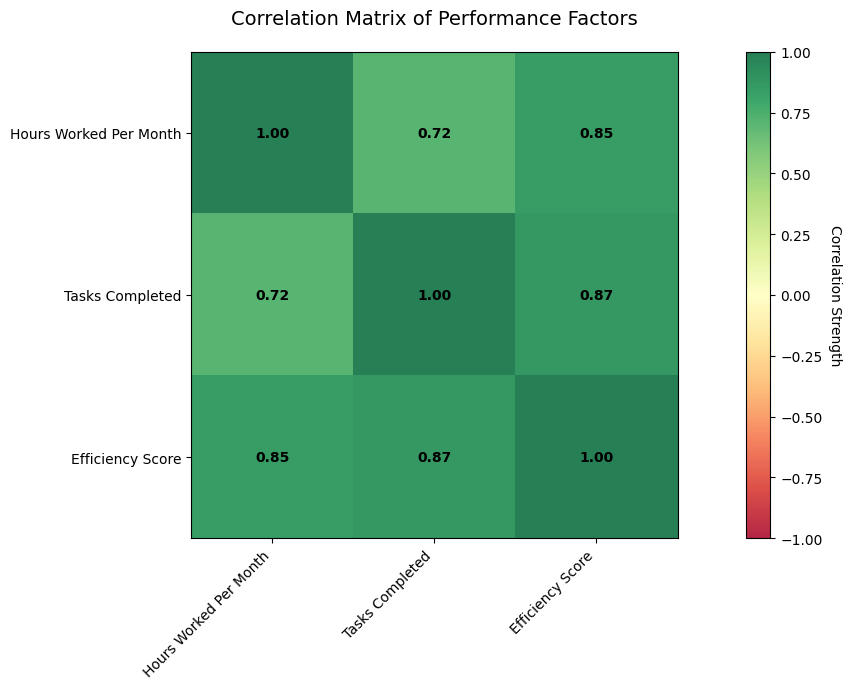

In [12]:
# Load the performance dataset
df_perf = pd.read_csv('assignment_CaseB_performance.csv')

# Calculate correlation between the three factors
factors = ['Hours Worked Per Month', 'Tasks Completed', 'Efficiency Score']
corr_matrix = df_perf[factors].corr()

# Create the Heatmap
fig, ax = plt.subplots(figsize=(14, 7))

# We use 'RdYlGn' (Red-Yellow-Green) colormap
# It is intuitive: Green for strong positive, Red for strong negative
im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1, alpha=0.85)

# Add colorbar for reference
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Correlation Strength", rotation=-90, va="bottom")

# Labeling axes
ax.set_xticks(np.arange(len(factors)))
ax.set_yticks(np.arange(len(factors)))
ax.set_xticklabels(factors)
ax.set_yticklabels(factors)

# Rotate x-labels for better fit
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Add numerical annotations inside the boxes
for i in range(len(factors)):
    for j in range(len(factors)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                ha="center", va="center", color="black", fontweight='bold')

plt.title("Correlation Matrix of Performance Factors", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

**Correlation Analysis and Observations**

1. Do employees who work more hours generally complete more tasks?

   **Positive relationship between hours worked vs. tasks completed**
   - Observation: The correlation between "Hours Worked Per Month" and "Tasks Completed" is $0.72$
   - Conclusion: Yes, employees who work more hours generally complete more tasks. A value of $0.72$ indicates a strong positive relationship. This means that as working hours increase, the number of completed tasks also tends to increase.</br> 
     
2. Which factors have the strongest positive or negative correlation, and what might this indicate about employee productivity in each department? 
    **The strongest relationship exists between Tasks Completed and Efficiency Score ($r = 0.87$).**
    - This suggests that employees who complete more tasks also tend to have higher efficiency scores.
    - It may indicate that productive employees are not only completing more work, but also working effectively.
    - This shows that productivity is not only about working longer hours, but also about how efficiently tasks are completed.

3. Negative Correlations
In this analysis, we found **no negative correlations**.
- The correlations between variables, $r$ score, are more than $0$ (positive).
- The three performance factors: Hours Worked, Tasks Completed, and Efficiency show strong positive relationships.
- This indicates that increased effort (hours) is generally associated into higher output (tasks) without sacrificing the quality of work (efficiency).

**Colormap Justification**

I chose the **RdYlGn (Red-Yellow-Green)** colormap because:
- It provides an intuitive visual metaphors for performance data like a traffic light where most people instinctively know what these colors mean without looking at the labels.
- Since correlation values range from -1 to +1, this diverging color scale clearly shows the direction of the relationship:
    - Green represents positive correlation.
    - Red represents negative correlation.
    - Yellow represents weak or neutral correlation.
- This makes the heatmap 'scannable' for quick decision making because it highlights both the direction and the strength of the relationships.
- The color hue shows whether the relationship is positive or negative. For example, green shows a positive relationship, while red shows a negative relationship.
- The intensity of the color (Dark Green vs Pale Yellow) tells you how strong that relationship is. A very dark green square tells you two factors are almost identical.
- In this dataset, most of the matrix appears in shades of green, which makes it clear that all performance factors in this department are working together harmoniously.

## Task 2: Identify employees’ performance

A radar chart was used to show the performance of all 10 employees in one figure.
Interpretation in a radar chart:
- If a point is near the center, the score is low.
- If a point is near the outer edge, the score is high.
- If the shape is large and balanced, the employee has well-rounded performance.
- If the shape has long spikes in some areas, the employee may be a specialist, meaning they perform very well in some factors but lower in others.

**Design choices for readability**
1. **Min-Max Normalization**: I scaled all data between $0$ and $1$ to make the chart possible to read.

    **Normalizing** the data before visualizing is important because without normalization "Hours Worked" (max 180) would look huge and "Tasks Completed" (max 50) would look tiny. By scaling everything from 0 to 1, we make it fair so we can compare "Hours" and "Satisfaction" on the same chart.

2. **Transparency (Alpha)**: with 10 employees, the shapes overlap significantly, so I made the "fill" color see-through. This keeps the chart from looking like a solid blob of ink. By lowering the Alpha (transparency), we turn those solid shapes into "tissue paper". In this code, I set the line plot 0.7 so the "edges" of each employee are sharp and clear and the fill 0.1 (very see-through) so we can see the grid and the other employees underneath.

3. **Distinct Color Palette**: by default, Matplotlib uses a set of distinct colors which gives each employee a different color. This helps each employee have a clear visual identity in the chart, especially when combined with the legend.
  
4. **Legend**: placed outside the chart so it doesn't cover up the data points or overlap with the employee performance shapes.

*Using Alpha shows that we care about data integrity, making sure every single data point is visible to the viewer.*

,Employee,Hours Worked Per Month,Tasks Completed,Efficiency Score,Attendance Rate,Customer Satisfaction
0,EMP1,0.333,0.583,0.333,1.000,0.583
1,EMP2,0.667,0.333,0.667,0.300,0.167
2,EMP3,0.000,0.000,0.000,0.500,0.000
3,EMP4,1.000,1.000,1.000,0.800,1.000
4,EMP5,0.500,0.833,0.867,0.700,0.833
5,EMP6,0.167,0.167,0.133,0.000,0.333
6,EMP7,0.833,0.500,0.467,0.900,0.667
7,EMP8,0.333,0.083,0.267,0.500,0.500
8,EMP9,0.667,0.250,0.533,0.200,0.250
9,EMP10,1.000,0.750,0.800,0.600,0.917


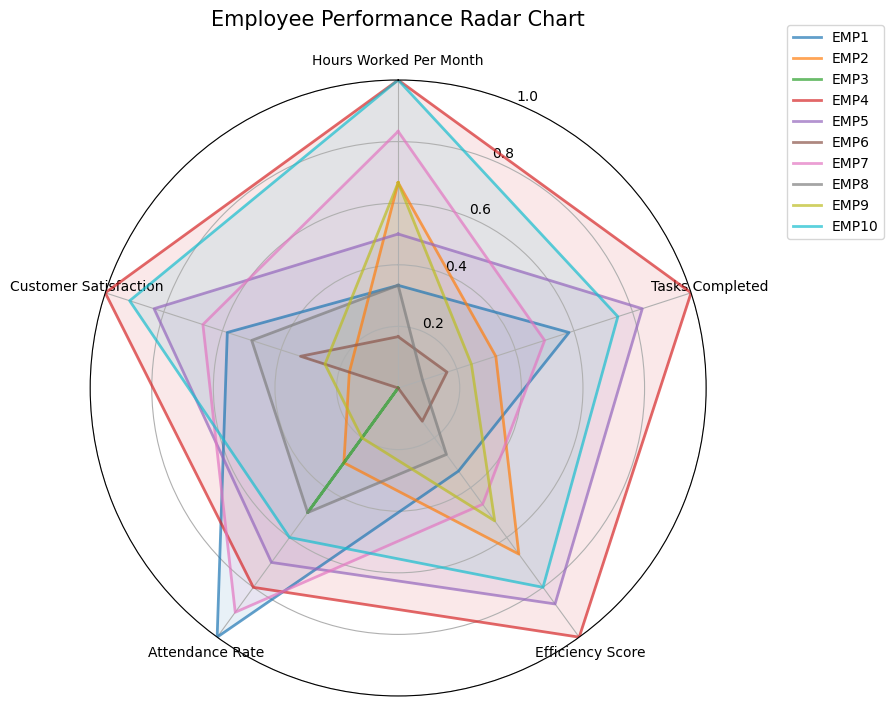

In [9]:
# Define the dimensions
labels = ['Hours Worked Per Month', 'Tasks Completed', 'Efficiency Score', 
          'Attendance Rate', 'Customer Satisfaction']

# Normalization (Crucial: puts different scales like 180 and 50 on a 0-1 range)
df_norm = df_perf.copy()
for label in labels:
    df_norm[label] = (df_perf[label] - df_perf[label].min()) / (df_perf[label].max() - df_perf[label].min())

# Setup Radar Chart Geometry
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Close the circle

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Plot each employee
for i, row in df_norm.iterrows():
    values = row[labels].tolist()
    values += values[:1]  # Close the circle
    ax.plot(angles, values, linewidth=2, label=row['Employee'], alpha=0.7)
    ax.fill(angles, values, alpha=0.1)

# Fix the chart labels
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0, 1) # Normalized range

plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.title('Employee Performance Radar Chart', size=15, pad=20)

# Show the norm table and use .round(3) to keep it clean and just type the variable name at the end
display(
    df_norm.style
    .format(precision=3)  
    .set_caption("Normalized Employee Performance Data")
    .set_table_styles([{
        'selector': 'caption',
        'props': [
            ('font-weight', 'bold'),
            ('font-size', '16px'),
            ('color', 'black')
        ]
    }])
)

# Display the plot
plt.show()

**Analysis of Employee Performance**

1. **Well-Rounded Performers: EMP4 and EMP10**
   - EMP4 and EMP10: these two are well-rounded across all dimensions. Their shapes on the radar chart cover the largest area and are relatively symmetrical.
   - EMP4 is the top overall performer, hitting near the outer edge on almost every axis.
   - EMP10 is also very strong and consistent performance, especially in satisfaction and hours worked.
2. **Customer Satisfaction Excellence: EMP4**
   - EMP4 has the highest score in Customer Satisfaction. In the normalized data, EMP4 reached the maximum score ($1.0$, raw score: $90$).
   - EMP10 followed closely behind with a raw score of $89$.
3. **Noticeable Strengths and Weaknesses**
   - EMP1 (Specialized Strength): This employee shows a clear strength in **Attendance Rate** but are much weaker in terms of Hours Worked and Efficiency. This suggests that EMP1 is reliable in terms of attendance, but may not be among the most productive employees.
    - EMP3 (General Weakness): EMP3 has the smallest shape on the chart. This employee scores low in Tasks Completed, Efficiency, and Customer Satisfaction. This may indicate that EMP3 could benefit from additional training, guidance, or performance support.
    - EMP7 (High Effort but Lower Efficiency): EMP7 shows a strength in Hours Worked and Attendance but has lower scores in Efficiency and Tasks Completed. This suggests that EMP7 spends a lot of time working, but that time does not translate into as much completed work compared with stronger performers such as EMP4 or EMP5.
4. **Summary**
    - EMP4 appears to be the strongest overall performer
    - EMP10 also shows balanced and consistent performance
    - EMP1 is reliable but less productive
    - EMP3 may need support
    - EMP7 shows high effort but lower efficiency

# Part II: Interactive Data Visualization

Read and process datasets, visualize data with *Ipywidgets, Plotly, or other interactive visualization libraries*, analyze data using visualization techniques, and select an appropriate data representation based on the type of 
data and/or the question being asked.

## CT2. Interactive Visualization Based on Case A of Part I

### CT2-1. Categorical selection

Interactive scatter plot lets users select one or more companies to visualize their stock price trends over time.

In [21]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Data loading and sorting values by date
df = pd.read_csv('assignment_CaseA_data.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# Interactive plot function
def update_plot(companies):
    plt.figure(figsize=(14, 7))
    for company in companies:
        plt.scatter(df['date'], df[company], label=company, s=30, alpha=0.75)
    
    plt.title('Interactive Stock Price Trends')
    plt.xlabel('Date')
    plt.ylabel('Stock Price ($)')
    plt.legend(title='Companies', loc='upper left')
    plt.grid(True, linestyle='-', alpha=0.5)
    plt.xticks()
    plt.show()

# Widget setup for select multiple companies
company_selector = widgets.SelectMultiple(
    options=['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA'],
    value=['AMZN', 'TSLA'],
    description='Companies:',
    disabled=False
)

# Display plot and the widget control the display
interactive_plot = widgets.interactive(update_plot, companies=company_selector)
display(interactive_plot)

# Find the days when TSLA stock price is higher than AMZN
tsla_higher = df[df['TSLA'] > df['AMZN']].copy()

# Calculate the difference between TSLA and AMZN
tsla_higher['Difference'] = tsla_higher['TSLA'] - tsla_higher['AMZN']

# Find the day with the largest difference
max_row = tsla_higher.loc[tsla_higher['Difference'].idxmax()]

start_date = tsla_higher['date'].iloc[0].date()
end_date = tsla_higher['date'].iloc[-1].date()

# Print the result
print("TSLA stock price was higher than AMZN on several days.")
print(f"Overall date range: {start_date} to {end_date}")
print(f"Number of trading days: {len(tsla_higher)}")
print(f"The largest difference occurred on {max_row['date'].date()}.")
print(f"TSLA price: ${max_row['TSLA']:.2f}")
print(f"AMZN price: ${max_row['AMZN']:.2f}")
print(f"Difference: ${max_row['Difference']:.2f}")

interactive(children=(SelectMultiple(description='Companies:', index=(3, 4), options=('AAPL', 'MSFT', 'GOOGL',…

TSLA stock price was higher than AMZN on several days.
Overall date range: 2024-05-21 to 2024-09-27
Number of trading days: 70
The largest difference occurred on 2024-09-27.
TSLA price: $260.46
AMZN price: $187.97
Difference: $72.49


**Plot Observation and Analysis:**

- In the interactive visualization, TSLA and AMZN were selected as the default stocks to compare their stock price movements over time.
- The x-axis represents the date, while the y-axis represents the stock price in $.
- Based on the selected data, TSLA’s stock price was higher than AMZN on several trading days (2024-05-21 to 2024-09-27).
- During this period, TSLA was higher than AMZN for 70 trading days.
- The largest difference occurred on 2024-09-27.
- On that date, TSLA’s stock price was 260.46 USD, while AMZN’s stock price was 187.97 USD. This means TSLA was higher than AMZN by 72.49 USD.
- Overall, the plot shows that TSLA had stronger upward movement than AMZN during this period.

### CT2-2. Time window selection

A time window selector was added to allow users to choose a specific date range in the visualization. When the start and end dates are adjusted, the chart updates and highlights the selected period. The selected range is then used to calculate the average stock price for each company.

In [15]:
# Import libraries
import pandas as pd
import plotly.express as px # used to create the interactive line chart.
import ipywidgets as widgets # used to create the time range slider
from IPython.display import display, clear_output # display shows the widget and chart, clear_output removes the old chart before showing the updated one

# Load and sort data
df = pd.read_csv('assignment_CaseA_data.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True) # reset the row numbers after sorting, so the data is clean and ordered properly.

# Define companies
companies = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']

# Create date options for the time slider
date_options = [(date.strftime('%Y-%m-%d'), date) for date in df['date']] 

# Default selected time range
start_date = pd.Timestamp('2024-07-01')
end_date = pd.Timestamp('2024-08-30')

# Find the position of the start and end dates in the dataset
# These positions are used to set the default slider range
start_index = df.index[df['date'] >= start_date][0]
end_index = df.index[df['date'] <= end_date][-1]

# Time range slider only
time_slider = widgets.SelectionRangeSlider(
    options=date_options, # the slider uses the dataset dates
    index=(start_index, end_index), # set the default selected range
    description='Date Range:', # give the slider a label
    continuous_update=False, # the chart updates only after moving the slider, making it smoother
    layout=widgets.Layout(width='95%') # make the slider wide and easier to use
)

# Output area, creates a space where the chart and printed results will appear
output = widgets.Output()

# This function runs every time the selected time range changes
def update_chart(selected_dates): # input selected_dates contains the start and end dates chosen by the slider
    with output: # remove the previous chart before showing the new updated chart
        clear_output(wait=True) 
        
        # Get selected start and end dates from the slider
        selected_start = pd.to_datetime(selected_dates[0])
        selected_end = pd.to_datetime(selected_dates[1])
        
        # Filter data based on selected time range
        selected_range = df[
            (df['date'] >= selected_start) &
            (df['date'] <= selected_end)
        ]
        
        # Calculate average stock price for all companies in the selected range
        average_prices = selected_range[companies].mean()
        
        # Create the Plotly line chart for all companies
        fig = px.line(
            df,
            x='date',
            y=companies,
            title='Stock Price Comparison with Time Window',
            labels={
                'date': 'Date',
                'value': 'Price ($)',
                'variable': 'Company'
            }
        )
        
        # Add shaded selected time window
        fig.add_vrect(
            x0=selected_start,
            x1=selected_end,
            fillcolor='lightgray',
            opacity=0.3,
            layer='below',
            line_width=0,
            annotation_text='Selected Time Window',
            annotation_position='top left'
        )
        
        # Add average price into hover detail for each company
        for trace in fig.data:
            company = trace.name
            avg_price = average_prices[company]
            trace.customdata = [[avg_price]] * len(trace.x)
        
        # Customize hover tooltip
        fig.update_traces(
            hovertemplate=
            '%{fullData.name}: $%{y:.2f}<br>' +
            'Average in Selected Range: $%{customdata[0]:.2f}' +
            '<extra></extra>'
        )
        
        # Clean look
        fig.update_layout(
            template='plotly_white', # give a clean white background
            hovermode='x unified', # show all company values for the same date in one hover box
            legend_title_text='Company', # give the legend a title
            width=1000, # width and height control chart size
            height=600
        )

        # Set the format of the hover date to Jul 01, 2024
        fig.update_xaxes(
            hoverformat='%b %d, %Y'
        )

        # Show the chart and print summary
        fig.show()

# Connect time slider to chart
interactive_plot = widgets.interactive(
    update_chart,
    selected_dates=time_slider
)

display(interactive_plot, output)

interactive(children=(SelectionRangeSlider(continuous_update=False, description='Date Range:', index=(np.int64…

Output(outputs=({'output_type': 'display_data', 'data': {'application/vnd.plotly.v1+json': {'data': [{'hoverte…

**Plot Observation and Analysis:**

- When the start and end dates are changed in time range slider, the chart updates based on the selected period.
- The selected time window is visually highlighted in the chart, making it easier to focus on a specific period.
- The hover detail shows the stock price for each company on a selected date, together with the average stock price within the selected time range.
- For the required analysis, the selected time window was set from 2024-07-01 to 2024-08-30.
- **Between July 1 and August 30, 2024, AAPL’s stock price was around 223.12 USD on average**.
- The interactive feature is useful because it allows users to change the time window and immediately compare the average stock prices of different companies within that period.

## Case C: Interactive visualization of geographical data

The dataset contains city names, the countries where each city is located, the city's population, and the city's position (latitude and longitude).

## Task 3. Interactive visualization of population on a map

Interactive geographical visualization that presents a population overview and allows exploration of the area of interest.

### (1) Load and inspect the dataset to understand its structure and identify missing information

In [16]:
# Import libraries
import pandas as pd
import numpy as np

# Load the CSV file
df = pd.read_csv("assignment_CaseC_cities_populations.csv")

# Inspect the structure
print(f"{df.head()} \n")
print(f"{df.info()} \n")
print(f"{df.describe()} \n")

# Check missing values
print(f"\nMissing values: {df.isnull().sum()}")

# Show rows with missing population values
print("\nRows with missing values:")
missing_population = df[df["Population"].isnull()]
missing_population

       City      Country  Population  Latitude  Longitude
0     Kabul  Afghanistan   4273156.0   34.5253    69.1783
1  Kandahār  Afghanistan    614254.0   31.6200    65.7158
2     Herāt  Afghanistan    556205.0   34.3419    62.2031
3    Tirana      Albania    418495.0   41.3289    19.8178
4    Durrës      Albania    175110.0   41.3133    19.4458 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 638 entries, 0 to 637
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        638 non-null    object 
 1   Country     638 non-null    object 
 2   Population  633 non-null    float64
 3   Latitude    638 non-null    float64
 4   Longitude   638 non-null    float64
dtypes: float64(3), object(2)
memory usage: 25.0+ KB
None 

         Population    Latitude   Longitude
count  6.330000e+02  638.000000  638.000000
mean   1.940144e+06   18.418103   17.437278
std    4.486213e+06   25.032030   67.896566
min    4.700000e+01  -5

,City,Country,Population,Latitude,Longitude
390,Plymouth,Montserrat,NaN,16.7064,-62.2158
481,Edinburgh of the Seven Seas,"Saint Helena, Ascension, and Tristan da Cunha",NaN,-37.0675,-12.3105
482,Georgetown,"Saint Helena, Ascension, and Tristan da Cunha",NaN,-7.9286,-14.4119
530,King Edward Point,South Georgia And South Sandwich Islands,NaN,-54.2833,-36.5000
591,Charlotte Amalie,U.S. Virgin Islands,NaN,18.3420,-64.9331


**Initial data overview:**

- The dataset contains 638 rows and 5 columns: City, Country, Population, Latitude, and Longitude
- Population column has 5 missing values

**Handling missing population values**:
- I decided to keep them in the dataset instead of removing them. This allows the cities to still be included in the geographical visualization.
- Create a new column called `Population_missing`, it saves the information whether the Population value is missing or exist.
    - If the population value is missing, it returns True
    - If the population value exists, it returns False
- Find the median population value in the `Population` column (missing values are not included).
- Create a new column called `Population_for_map` used for the visualization
- Impute missing population values with the median population value in `Population_for_map` column
- This method does not estimate the real population of the missing cities. It is only used to make sure that all locations can be shown on the map.
- The original data was preserved, and the new column can be used safely for the map visualization.

In [17]:
# Keep the original Population column unchanged
df["Population_missing"] = df["Population"].isna()

# Find the median population value in the dataset
median_population = df["Population"].median()

# Create a new column for visualization
df["Population_for_map"] = df["Population"].fillna(median_population)

# Confirmation text
print("Missing population values have been handled.\n")
print("The column 'Population_missing' was created to identify missing population values.")
print("The column 'Population_for_map' was created for map visualization.")
print(f"Missing population values in 'Population_for_map' were replaced with the median population value: {median_population:,.0f}")
print(f"Number of missing values in original Population column: {df['Population'].isna().sum()}")
print(f"Number of missing values in Population_for_map column: {df['Population_for_map'].isna().sum()}")

Missing population values have been handled.

The column 'Population_missing' was created to identify missing population values.
The column 'Population_for_map' was created for map visualization.
Missing population values in 'Population_for_map' were replaced with the median population value: 383,257
Number of missing values in original Population column: 5
Number of missing values in Population_for_map column: 0


### (2) Create an interactive geographical scatter plot 

The plot shows city locations, with marker size based on city population, and marker color based on population density.

- Since the dataset does not include city area, real population density could not be calculated. Therefore, the color scale represents population distribution rather than true population density.
- So, both the marker size and marker color are based on city population values.
- The colormap used for the population distribution is YlOrRd (Yellow-Orange-Red), a standard ColorBrewer palette optimized for cartography. It is a sequential, multi-hue palette that is ideal for mapping continuous data across a wide range.

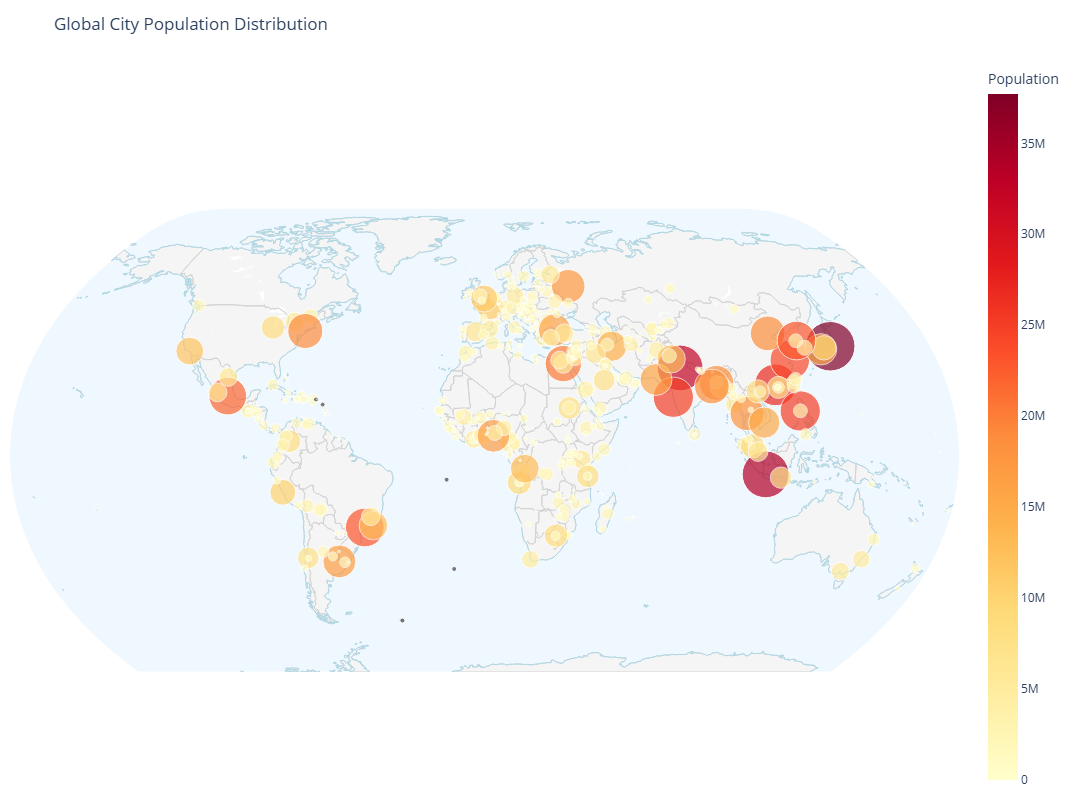

In [18]:
# Import libraries
import plotly.express as px
import pandas as pd

# Create Interactive Geographical Scatter Plot
fig = px.scatter_geo(
    df,
    lat="Latitude",
    lon="Longitude",
    hover_name="City",
    size="Population_for_map",# Marker size based on city population
    color="Population",       # Marker color based on population also  
    scope="world",
    projection="natural earth",
    hover_data={
        "Country": True,
        "Population": ":,.0f",
        "Latitude": False,
        "Longitude": False,
        "Population_for_map": False,
    },
    title="Global City Population Distribution",
    color_continuous_scale="YlOrRd",
    size_max=35,
    height=800
)

# Customize the layout for a professional look
fig.update_geos(
    showcountries=True,
    countrycolor="LightGray",
    showcoastlines=True,
    coastlinecolor="LightBlue",
    showland=True,
    landcolor="WhiteSmoke",
    showocean=True,
    oceancolor="AliceBlue",
    showframe=False,
    center={"lat": 10, "lon": 0},
    projection_scale=1
)

# Make the map fill the figure space better
fig.update_layout(
    autosize=True,
    margin={"r": 10, "t": 60, "l": 10, "b": 10}
)

fig.show()

**Plot Observation and Analysis:**

- The interactive map shows that the cities in the dataset are distributed across many regions of the world.
- Each marker represents one city, using latitude and longitude to show its geographical location.
- The sequential color scale makes it easy to distinguish lower and higher population values:
    - lower values are shown with brighter colors 
    - higher values are shown with darker colors
- The largest and brightest markers are mainly concentrated in highly populated regions

### (3) Population patterns in European countries

- The interactive map shows that city populations in Europe vary widely. 
- The European cities in the dataset have a very large population range:
    - Small settlements, such as Hvalba in the Faroe Islands, have around 713 people.
    - Large metropolitan cities, such as Moscow in Russia, have around 17.3 million people.
- The largest markers and strongest colors are mainly found in major capital cities and large metropolitan areas.
- The cities with the highest population intensity in Europe: Moscow, London, Paris, Madrid, Saint Petersburg, Berlin, and Barcelona.
- The pattern suggests that Europe’s urban population is unevenly distributed.
- A small number of large cities dominate the visualization, while many other cities have much smaller populations.
- This indicates that population is concentrated in major economic, political, and cultural centres.
- Since the dataset does not include city area, true population density cannot be calculated. Therefore, population values are used as a substitute measure.

## Task 4: Interactive Dashboard

### T4-1. Interactive bar chart of top N cities by population density

#### (1) Interactive bar chart of the top N cities

In [22]:
# Import libraries
import pandas as pd
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display

# Load the dataset
df = pd.read_csv("assignment_CaseC_cities_populations.csv")

# Make sure Population is numeric
df["Population"] = pd.to_numeric(df["Population"], errors="coerce")

# Keep the original Population column unchanged
df["Population_missing"] = df["Population"].isna()

# Find the median population value in the dataset
median_population = df["Population"].median()

# Create a new column for visualization
df["Population_for_map"] = df["Population"].fillna(median_population)

# Create a readable city label
df["City_Country"] = df["City"] + ", " + df["Country"]

# Create IntText widget for selecting top N cities
top_n_widget = widgets.IntText(
    value=10,
    description="Top N:",
    disabled=False
)

# Function to create the interactive bar chart
def plot_top_cities(n):
    # Make sure N is valid
    if n < 1:
        n = 1
    elif n > len(df):
        n = len(df)

    # Select top N cities with the largest populations
    top_cities = df.nlargest(n, "Population_for_map")

    # Sort for better horizontal bar chart display
    top_cities = top_cities.sort_values("Population_for_map", ascending=False)

    # Create interactive bar chart
    fig = px.bar(
        top_cities,
        x="City_Country",
        y="Population_for_map",
        color="Population_for_map",
        text="Population_for_map",
        hover_data={
            "City": True,
            "Country": True,
            "Population": ":,.0f",
            "Population_for_map": False,
            "Population_missing": False,
            "City_Country": False
        },
        title=f"Top {n} Cities by Population",
           color_continuous_scale="YlOrRd"
    )

    # Improve chart appearance
    fig.update_traces(
        texttemplate="%{text:,.0f}",
        textposition="outside",
        cliponaxis=False
    )

    max_population = top_cities["Population_for_map"].max()

    fig.update_layout(
        xaxis_title="City",
        yaxis_title="Population",
        coloraxis_colorbar=dict(title="Population"),
        height=600,
        margin={"r": 120, "t": 80, "l": 80, "b": 180}
    )

    fig.update_xaxes(
        tickangle=-90
    )
    
    fig.update_yaxes(
        range=[0, max_population * 1.15]

    )
    
    fig.show()

# Create interactive output
interactive_chart = widgets.interactive_output(
    plot_top_cities,
    {"n": top_n_widget}
)

# Display widget and chart
display(top_n_widget, interactive_chart)

IntText(value=10, description='Top N:')

Output()

**Plot Observation and Analysis:**

- The chart use IntText widget allows the user to change N and explore different numbers of top cities interactively.
- Tokyo, Japan has the highest population, with around 37.7 million people.
- The largest city populations in the dataset are mainly concentrated in Asia.
- The chart shows an uneven population distribution, where a few very large metropolitan areas dominate the dataset.
- The largest cities are mostly national capitals, economic centres, or major metropolitan regions.
- The color intensity helps show the population differences more clearly:
    - lower population values are shown with brighter colors 
    - higher population values are shown with darker colors
- This analysis is based on population size, not real population density.

#### (2) Identify the top 10 cities with the largest population

Geographical patterns from the map:
- The top 10 cities are not evenly distributed around the world.
- Most of the largest cities are located in Asia.
- Asia dominates the dataset in terms of the largest city populations. Asian cities in the top 10 include:
    - Tokyo, Japan
    - Jakarta, Indonesia
    - Delhi, India
    - Guangzhou, China
    - Mumbai, India
    - Manila, Philippines
    - Shanghai, China
    - Seoul, South Korea
- A very large urban populations also exist in Latin America. There are two cities in the top 10 located in Latin America:
    - São Paulo in Brazil
    - Mexico City in Mexico
- The population range among the top 10 cities is also large.
    - Tokyo has around 37.7 million people, while Mexico City has around 21.8 million people.
    - This means that even among the largest cities, there is a difference of around 15.9 million people between the largest and the tenth-largest city.
- Overall, the visualization shows an uneven global population pattern, where a small number of very large cities dominate the upper population range.

### T4-2. Interactive Mini-Dashboard (Linking and Brushing)

A mini dashboard to explore the relationship between cities' geographic locations and their populations using linking and brushing to allow interactive data exploration across multiple views.

#### (3) Visualize the interactive geographic visualization and interaction bar chart together

- This dashboard explores the relationship between city location and population.
- It contains two linked views: a geographic scatter plot and a bar chart.
- The geographic scatter plot shows the location of each city using latitude and longitude.
- Marker size and color represent population, so larger and darker markers indicate cities with higher population values.
- The bar chart sorts the selected cities by population, making it easier to compare which selected cities have larger or smaller populations.
- The country legend beside the bar chart shows the countries represented in the selected cities.
- Missing population values were replaced using the median population value, so cities with missing data can still be included in the visualization.

#### (4) Dynamically update to reflect only the selected data (filtering) or highlight the selected data in both plots
- Users can brush or select cities on the map using the lasso or box selection tool.
    - After cities are selected on the map, the bar chart updates dynamically to show the population of only the selected cities.
- Users can also click a bar in the bar chart, and the map will highlight the corresponding city location.
- This linking and brushing interaction helps users compare population values within a selected geographic area.
- Both plots share the same color encoding to make it easier to understand

In [20]:
# Import libraries
import pandas as pd
import plotly.graph_objects as go
from dash import Dash, dcc, html, Input, Output, ctx
from plotly.colors import sample_colorscale

# 1. Load and prepare data
df = pd.read_csv("assignment_CaseC_cities_populations.csv")

# Make sure Population is numeric
df["Population"] = pd.to_numeric(df["Population"], errors="coerce")

# Mark missing population values
df["Population_missing"] = df["Population"].isna()

# Impute missing values using median
median_population = df["Population"].median()
df["Population_for_map"] = df["Population"].fillna(median_population)

# Create readable city label
df["City_Country"] = df["City"] + ", " + df["Country"]

# Create safe text columns for hover display
df["Population_original_text"] = df["Population"].apply(
    lambda x: "Missing" if pd.isna(x) else f"{x:,.0f}"
)

df["Population_used_text"] = df["Population_for_map"].apply(
    lambda x: f"{x:,.0f}"
)

df["Population_missing_text"] = df["Population_missing"].map({
    True: "Yes",
    False: "No"
})

# Remove rows without coordinates
df = df.dropna(subset=["Latitude", "Longitude", "Population_for_map"]).copy()

# Reset index and create row_id for linking
df = df.reset_index(drop=True)
df["row_id"] = df.index

# 2. Create colors using YlOrRd based on population values

population_min = df["Population_for_map"].min()
population_max = df["Population_for_map"].max()

# Normalize population values to range 0-1
df["population_normalized"] = (
    (df["Population_for_map"] - population_min) /
    (population_max - population_min)
)

# Use YlOrRd color scale based on population
df["city_color"] = df["population_normalized"].apply(
    lambda x: sample_colorscale("YlOrRd", [x])[0]
)

# 3. Create marker size based on population

population_max = df["Population_for_map"].max()

# Default cities to show before the user brushes/selects anything on the map
default_bar_df = df.sample(
    n=min(10, len(df)),
    random_state=42
).sort_values(
    "Population_for_map",
    ascending=False
)

df["marker_size"] = 8 + (
    df["Population_for_map"] / population_max
) * 22

# 4. Create Dash app

app = Dash(__name__)

app.layout = html.Div([

    html.H2(
    "Interactive Mini-Dashboard: City Location and Population",
    style={
        "fontFamily": "Open Sans, Arial, sans-serif",
        "fontWeight": "600"
        }
    ),

    html.P(
        "Use the lasso or box selection tool on the geo map to select cities. "
        "The bar chart will update to show the population of the selected cities. "
        "Click a bar to highlight the city location on the map."
    ),

    html.P(
        id="message",
        style={
            "textAlign": "left"
        }
    ),

    html.Div([

        # View_1: Geo map
        html.Div([
            dcc.Graph(
                id="geo-map",
                style={"height": "560px", "width": "100%"},
                config={
                    "displayModeBar": True,
                    "scrollZoom": True
                }
            )
        ], style={
            "flex": "1",
            "minWidth": "0"
        }),

        # View_2: Bar chart + legend
        html.Div([

            html.Div([
                dcc.Graph(
                    id="bar-chart",
                    style={"height": "560px", "width": "100%"},
                    config={"displayModeBar": True}
                )
            ], style={
                "flex": "0 0 75%",
                "minWidth": "0"
            }),

            html.Div([
                html.H4("Country"),
                html.Div(id="bar-legend")
            ], style={
               "flex": "0 0 25%",
               "height": "520px",
               "overflowY": "auto",
               "padding": "8px",
               "fontSize": "12px",
               "fontFamily": "Open Sans, Arial, sans-serif"
            })

        ], style={
            "display": "flex",
            "flex": "1",
            "minWidth": "0"
        })

    ], style={
        "display": "flex",
        "gap": "10px",
        "width": "98%",
        "boxSizing": "border-box",
        "padding": "12px",
        "border": "2px solid #cccccc",
        "borderRadius": "12px",
        "boxShadow": "2px 2px 8px rgba(0,0,0,0.1)",
        "backgroundColor": "white",
        "margin": "auto"
    })

], style={
    "width": "100%",
    "maxWidth": "1600px",
    "margin": "auto",
    "padding": "10px"
})


# 5. Callback for both views

@app.callback(
    Output("geo-map", "figure"),
    Output("bar-chart", "figure"),
    Output("message", "children"),
    Output("bar-legend", "children"),
    Input("geo-map", "selectedData"),
    Input("bar-chart", "clickData")
)

def update_dashboard(selectedData, clickData):

    # ----------------------------
    # Check map selection
    # ----------------------------

    map_selection_active = (
        selectedData is not None and
        "points" in selectedData and
        len(selectedData["points"]) > 0
    )

    if map_selection_active:
        selected_ids = [p["customdata"][0] for p in selectedData["points"]]

        selected_df = df[df["row_id"].isin(selected_ids)].copy()

        selected_df = selected_df.sort_values(
            "Population_for_map",
            ascending=False
        )

        message = (
            f"{len(selected_df)} cities selected on the geo map. "
            "The bar chart shows the population of all selected cities."
        )

    else:
        selected_df = default_bar_df.copy()
    
        message = (
            "No cities selected yet. The bar chart shows 10 random cities by default. "
            "Use the lasso or box selection tool on the geo map to update it."
        )
        

    # View_1: Geo scatter plot

    map_fig = go.Figure()

    map_fig.add_trace(
        go.Scattergeo(
            lat=df["Latitude"],
            lon=df["Longitude"],
            mode="markers",
            marker=dict(
                size=df["marker_size"],
                color=df["city_color"],
                line=dict(width=1, color="black"),
                opacity=0.70
            ),
            customdata=df[
                [
                    "row_id",
                    "City",
                    "Country",
                    "Population_original_text",
                    "Population_used_text",
                    "Population_missing_text"
                ]
            ].to_numpy(),
            hovertemplate=(
                "<b>%{customdata[1]}</b><br>"
                "Country: %{customdata[2]}<br>"
                "Population: %{customdata[3]}"
                "<extra></extra>"
            ),
            selected=dict(
                marker=dict(
                    opacity=1,
                    size=20
                )
            ),
            unselected=dict(
                marker=dict(
                    opacity=0.20
                )
            ),
        )
    )

    map_fig.update_geos(
        showcountries=True,
        countrycolor="LightGray",
        showcoastlines=True,
        coastlinecolor="LightBlue",
        showland=True,
        landcolor="WhiteSmoke",
        showocean=True,
        oceancolor="AliceBlue",
        showframe=False,
        center={"lat": 10, "lon": 0},
        projection_scale=1,
        projection_type="natural earth"
    )

    map_fig.update_layout(
        title="City Populations on Map",
        height=560,
        dragmode="lasso",
        margin={"r": 0, "t": 40, "l": 0, "b": 0},
        showlegend=False
    )

    # View_2: Bar chart of selected cities only

    bar_fig = go.Figure()

    if len(selected_df) > 0:
        bar_fig.add_trace(
            go.Bar(
                x=selected_df["City"],
                y=selected_df["Population_for_map"],
                text=selected_df["Population_for_map"],
                marker=dict(
                    color=selected_df["city_color"],
                    line=dict(color="black", width=1)
                ),
                customdata=selected_df[
                    [
                        "row_id",
                        "City",
                        "Country",
                        "Population_original_text",
                        "Population_used_text",
                        "Population_missing_text",
                        "Latitude",
                        "Longitude"
                    ]
                ].to_numpy(),
                hovertemplate=(
                    "Country: %{customdata[2]}<br>"
                    "City Name:%{customdata[1]}<br>"
                    "Population: %{customdata[3]}"
                    "<extra></extra>"
                ),
                texttemplate="%{text:,.0f}",
                textposition="outside",
                cliponaxis=False,
            )
        )

        max_pop = selected_df["Population_for_map"].max()
        bar_fig.update_yaxes(range=[0, max_pop * 1.2])

        bar_title = "Population of Cities"

    else:
        bar_fig.add_annotation(
            text="Select cities on the geo map to show their population here.",
            xref="paper",
            yref="paper",
            x=0.5,
            y=0.5,
            showarrow=False,
            font=dict(size=16)
        )

        bar_title = "Population of Cities"

    bar_fig.update_layout(
        title=bar_title,
        height=560,
        xaxis_title="City",
        yaxis_title="Population",
        clickmode="event+select",
        showlegend=False,
        margin={"r": 10, "t": 60, "l": 70, "b": 170}
    )

    bar_fig.update_xaxes(
        tickangle=90
    )

    bar_fig.update_yaxes(
        tickformat=","
    )

    # Legend beside bar chart

    if len(selected_df) > 0:
        country_legend = (
            selected_df
            .groupby("Country", as_index=False)
            .agg(
                Number_of_Cities=("City", "count"),
                Total_Population=("Population_for_map", "sum"),
                Legend_Color=("city_color", "first")
            )
            .sort_values("Country")
        )
    
        legend_items = []
    
        for _, row in country_legend.iterrows():
            legend_items.append(
                html.Div([
                    html.Span(
                        style={
                            "display": "inline-block",
                            "width": "12px",
                            "height": "12px",
                            "backgroundColor": row["Legend_Color"],
                            "border": "1px solid black",
                            "marginRight": "6px"
                        }
                    ),
                    html.Span(
                        f"{row['Country']} "
                    )
                ], style={
                    "marginBottom": "6px",
                    "display": "flex",
                    "alignItems": "center"
                })
            )
    
    else:
        legend_items = [
            html.P("No selected countries yet.")
        ]

    # Optional: click a bar to highlight exact city on the map

    if ctx.triggered_id == "bar-chart" and clickData is not None:
        clicked_id = clickData["points"][0]["customdata"][0]
        clicked_city = df[df["row_id"] == clicked_id]

        if len(clicked_city) > 0:
            city_name = clicked_city.iloc[0]["City"]
            country_name = clicked_city.iloc[0]["Country"]
            city_lat = clicked_city.iloc[0]["Latitude"]
            city_lon = clicked_city.iloc[0]["Longitude"]

            map_fig.data[0].marker.opacity = 0.20

            map_fig.add_trace(
                go.Scattergeo(
                    lat=clicked_city["Latitude"],
                    lon=clicked_city["Longitude"],
                    mode="markers+text",
                    marker=dict(
                        size=30,
                        color="deeppink",
                        line=dict(width=2, color="black")
                    ),
                    text=clicked_city["City"],
                    textposition="top center",
                    name="Clicked city",
                    showlegend=False,
                    hovertext=clicked_city["City_Country"],
                    hovertemplate="%{hovertext}<extra></extra>"
                )
            )

            map_fig.update_geos(
                center=dict(
                    lat=city_lat,
                    lon=city_lon
                ),
                projection_scale=4
            )

            message = f"Selected from bar chart: {city_name}, {country_name}"

    return map_fig, bar_fig, message, legend_items
    

# 6. Run dashboard
app.run(debug=False, jupyter_mode="inline", port=8053)

**Plot Analysis:**

- The dashboard helps users explore the relationship between where cities are located and how large their populations are.
- The map is useful for identifying geographic patterns, such as clusters of cities in specific regions or continents.
- The bar chart supports more precise comparison because population differences are easier to compare using bar length and color.
- The linking and brushing interaction improves exploration because users can focus on a specific geographic area and immediately compare the populations of only the selected cities.
- Using both marker size and color for population strengthens the visual encoding, because highly populated cities become more noticeable on the map.
- The click interaction from the bar chart back to the map is useful because it helps users identify the exact location of a city after comparing its population in the bar chart.
- The median imputation method prevents missing population values from being removed, but it should be interpreted carefully because imputed values are estimated values, not original population values.
- Overall, the dashboard provides an effective way to explore city population patterns interactively across geographic and comparative views.

# Conclusion

In conclusion, this assignment applied the main concepts from the Visual Data Analytics labs by using Python visualization libraries to process, visualize, and analyze the datasets. The work covered both static visualization tasks and interactive visualization techniques, matching the assignment focus on data collecting, processing, plotting, and interaction techniques.

The final notebook includes data preparation, handling of missing population values using median imputation, readable visual encodings, titles, axis labels, hover information, and legends. These elements help make the visualization understandable and support the assignment requirement that answers should be justified with appropriate visualizations.

Overall, the completed work demonstrates how static and interactive visualization can make datasets easier for user to explore and interpret. These visualizations helps user identify important information and can support better decision making.